In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':
    # Hyperparameters
    data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    # data_str = "simulation"
    batch_size = 1          # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 8             # number of heads
    ncum = 8                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 100
    target_sample_size = 8     
    nrepp = 10

    # Set the random seed for reproducibility
    seed = 1
    torch.manual_seed(seed)
    
    # load real data
    data, maxlen = load_real_data(data_str)
    

    n = len(data)
    p = data[0].shape[1]
    print("Sample size: ", len(data), "\n")
    
    train_dataset = data
    
    predindex = 9



    mask_pairwise = create_custom_mask_pair(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    
    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device)

    model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, None, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")


    print("distance between pair par:", model.multiheadattn.distance_between_two_positions_weight.item(), "\n")
    print("distance to end par:", model.multiheadattn.distance_to_end_weight.item())



Sample size:  882 

Number of Parameters 420
EPOCH 1:
avg_loss: 17.51132
EPOCH 11:
avg_loss: 14.30122
EPOCH 21:
avg_loss: 13.95128
EPOCH 31:
avg_loss: 13.92733
EPOCH 41:
avg_loss: 13.91933
EPOCH 51:
avg_loss: 13.90680
EPOCH 61:
avg_loss: 13.88534
EPOCH 71:
avg_loss: 13.88024
EPOCH 81:
avg_loss: 13.88007
EPOCH 91:
avg_loss: 13.81349
Execution time: 58.019802 seconds
distance between pair par: -0.08612345159053802 

distance to end par: -0.05784541741013527


In [4]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [5]:
print_p_values(avepval, stdpval)

Variable 1: 0.5647 ± 0.23
Variable 2: 0.6080 ± 0.23
Variable 3: 0.1875 ± 0.14
Variable 4: 0.0060 ± 0.01
Variable 5: 0.0998 ± 0.14
Variable 6: 0.2031 ± 0.09
Variable 7: 0.7765 ± 0.11
Variable 8: 0.4529 ± 0.09
Variable 9: 0.2166 ± 0.11
Variable 10: 0.7723 ± 0.39


In [ ]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall, nrepp)    

Repetition 1/10
Repetition 2/10
Repetition 3/10
Repetition 4/10
Repetition 5/10
Repetition 6/10
Repetition 7/10
Repetition 8/10
Repetition 9/10
Repetition 10/10


In [ ]:
with open(f"./notebooks/statistical_testing/statistical_testing_{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write(f"For combination sample size: {target_sample_size} \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    

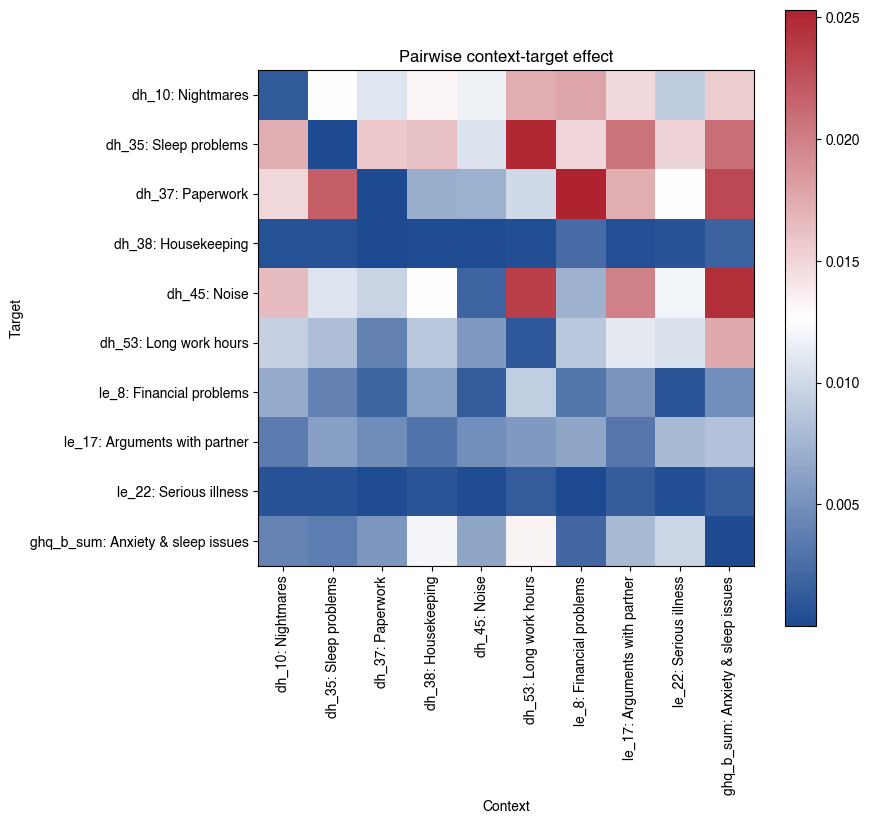

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [ ]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, data_str, "./notebooks")

In [ ]:
# Get sorted indices
sorted_indices = torch.argsort(avepval)

variable_names = [
            "dh_10: Nightmares",
            "dh_35: Sleep problems",
            "dh_37: Paperwork",
            "dh_38: Housekeeping",
            "dh_45: Noise",
            "dh_53: Long work hours",
            "le_8: Financial problems",
            "le_17: Arguments with partner",
            "le_22: Serious illness",
            "ghq_b_sum: Anxiety & sleep issues"
        ]

variable_names = [variable_names[i] for i in sorted_indices]

# for loop print name average and standard deviation
for i in range(avepval.shape[0]):
    print(f"Variable {variable_names[i]}: {avepval[sorted_indices[i]]:.4f} ± {stdpval[sorted_indices[i]]:.2f}")

# print(variable_names)
# print(avepval[sorted_indices])
# print(stdpval[sorted_indices])

Variable dh_53: Long work hours: 0.0074 ± 0.01
Variable dh_38: Housekeeping: 0.0188 ± 0.03
Variable le_22: Serious illness: 0.0687 ± 0.04
Variable le_17: Arguments with partner: 0.1418 ± 0.07
Variable dh_45: Noise: 0.3015 ± 0.18
Variable dh_37: Paperwork: 0.4838 ± 0.17
Variable dh_10: Nightmares: 0.7394 ± 0.15
Variable dh_35: Sleep problems: 0.7732 ± 0.09
Variable ghq_b_sum: Anxiety & sleep issues: 0.8327 ± 0.35
Variable le_8: Financial problems: 0.9318 ± 0.05
